<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/borges/RA1_TP3/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_3%2C_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TP3 - Introducción a clasificaión y regresión

In [131]:
# @title *Esta celda importa utilidades comunes al colab*
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Scikit-learn: preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Scikit-learn: modelos
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.neighbors import KNeighborsRegressor

# Scikit-learn: métricas
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, PredictionErrorDisplay)

import warnings
warnings.filterwarnings("ignore")

# Reproducibilidad — fijar siempre antes de cualquier split o modelo
SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Entorno configurado.")

Entorno configurado.


#Ejercicio 1 - Modelado de regresión (Alex)


---
**Dataset:** `propiedades.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/2026

>El equipo de analítica de la empresa inmobiliaria necesita un modelo capaz de estimar el precio de una propiedad a partir de sus características. El objetivo ya no es describir los datos, sino construir un predictor evaluable y defendible.


##1. Construcción del pipeline

##2. Entrenamiento y comparación de modelos

##3. Optimización

#Ejercicio 2 - Modelado de clasificación (Santi)

---
**Dataset:** `clientes_churn.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/26

>La empresa de telecomunicaciones necesita anticipar qué clientes tienen alta probabilidad de abandonar el servicio en el próximo mes, con el objetivo de intervenir a tiempo con ofertas de retención. En este contexto de negocio, detectar un cliente que se va y no actuar tiene un costo estimado de 50000 (pérdida de valor del cliente).
Intervenir innecesaiamente sobre un cliente que no pensaba irse tiene un costo de 8000 (costo de la promoción o descuento otorgado).

##1. Construcción del pipeline

##2. Entrenamiento y comparación de modelos

##3. Optimización

#Ejercicio 3 - Modelado en ausencia de contexto (Borges)

---
**Dataset:** `dataset_desconocido.csv`  
**Grupo:** Numero 8  
**Integrantes:** Acosta alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/26

>En la etapa de exploración se descrubrió que la estructura de separación entre clases en este dataset es no lineal. Ahora se traducirá esa intuición en decisiones concretas de modelado y verificará empiricamente su validez.

##1. Preparación y preprocesamiento de los datos

En primera instancia, se realiza la carga del dataset a usar y un repaso de las hipótesis planteadas en la etapa anterior (EDA).

In [132]:
df = pd.read_csv("dataset_desconocido.csv")

print(f"Dimensiones: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nFaltantes:\n{df.isnull().sum()}")
print(f"\nPrimeras filas:")
df.head()

Dimensiones: (1000, 7)

Tipos de datos:
x1        float64
x2        float64
x3        float64
x4        float64
x5        float64
x6        float64
target      int64
dtype: object

Faltantes:
x1        19
x2        13
x3        18
x4         0
x5         0
x6         0
target     0
dtype: int64

Primeras filas:


,x1,x2,x3,x4,x5,x6,target
0,-2.11,1.86,-1.20,0.81,0.67,-0.40,0
1,0.01,-1.05,-0.75,-0.38,-1.38,-0.12,1
2,5.40,-5.65,-0.80,-1.73,-1.72,-1.52,1
3,1.04,-0.14,0.18,-1.26,-1.34,0.75,1
4,-1.00,-1.73,1.53,-1.94,0.81,0.15,0


Cómo en la etapa anterior no se realizó una limpieza por desconocimiento del contexto y falta de herramientas para saber si en primera instancia imputar o eliminar los valores faltantes, actualmente se tomó la decisión de eliminar estos valores dado que representan un 5% de los datos del dataset (50 valores faltantes sobre 1000).

In [133]:
df_cleaned = df.dropna()
print(f"Dimensiones después de eliminar nulos: {df_cleaned.shape}")
print(f"Faltantes después de eliminar nulos:\n{df_cleaned.isnull().sum()}")

Dimensiones después de eliminar nulos: (950, 7)
Faltantes después de eliminar nulos:
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
target    0
dtype: int64


El objetivo mediante el siguiente desarrollo es contrastar empíricamente las siguientes hipótesis planteadas en la etapa anterior:
1. Como el target se encuentra balanceado, las métricas de evaluación serán más fiables.
2. Las variables `x1` y `x2` son las únicas altamente relevantes debido a sus distribuciones diferenciadas por clase.
3. `x3`, `x4`, `x5` y `x6` son ruido (distribuciones con alto solapamiento o idénticas por clase). Deben ser eliminadas para evitar sobreajuste y degradación del modelo.
4. La relación entre `x1` y `x2` es circular, no linealmente separable en su espacio original.
5. Para `x1` y `x2`, es crucial aplicar una transformación cuadrática o calcular la distancia desde el origen, ya que esto lineariza la frontera de decisión.
6. Existen outliers en `x1` y `x2`. Aunque no impiden la separabilidad visual con transformaciones, su manejo podría mejorar la robustez del modelo.

####1.2 Definición de features y target

In [134]:
# Variable objetivo
TARGET = "target"

# Features que usaremos (basado en las hipótesis de relevancia)
FEATURES = ["x1", "x2"]

# Variables que excluimos y por qué:
excluidas = {
    "x3": "Ruido aleatorio: solapamiento casi perfecto entre clases observado en el EDA.",
    "x4": "Ruido puro: distribuciones idénticas por clase y correlación cero.",
    "x5": "Ruido puro: detectado como no relevante en la etapa de exploración.",
    "x6": "Ruido puro: su inclusión podría degradar el desempeño del modelo.",
}

print("Features seleccionadas:", FEATURES)
print(f"\nVariables excluidas:")
for var, razon in excluidas.items():
    print(f"- {var}: {razon}")

Features seleccionadas: ['x1', 'x2']

Variables excluidas:
- x3: Ruido aleatorio: solapamiento casi perfecto entre clases observado en el EDA.
- x4: Ruido puro: distribuciones idénticas por clase y correlación cero.
- x5: Ruido puro: detectado como no relevante en la etapa de exploración.
- x6: Ruido puro: su inclusión podría degradar el desempeño del modelo.


Se excluye la variable `x3` debido a que en el análisis exploratorio (EDA) se observó un solapamiento casi perfecto entre clases. Al no presentar patrones de separación útiles, se comporta como ruido aleatorio, similar a `x4`, `x5` y `x6`.

####1.3 División train/test y definición del pipeline

Para evitar data leakage, antes determinar que hacer con los outliers, se realiza una división train/test, así se puede realizar un posterior escalado estandar sin que este sea contaminado implicitamente por el modelo de test.

In [135]:
X = df_cleaned[FEATURES]
y = df_cleaned[TARGET]

# Dividimos usando stratify directamente sobre y, ya que es una clasificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print(f"Tamaño entrenamiento: {len(X_train)} muestras ({len(X_train)/len(df_cleaned)*100:.0f}%)")
print(f"Tamaño test:          {len(X_test)} muestras ({len(X_test)/len(df_cleaned)*100:.0f}%)")

Tamaño entrenamiento: 760 muestras (80%)
Tamaño test:          190 muestras (20%)


Se eligió una división 80/20 ya que es una proproción aceptada para que el modelo aprenda los patrones con pocas muestras.

Para el análisis de los outliers, se usó el método del Rango Intercuartílico (IQR) para detectar valores extremos en variables de entrada (X_train), como se eliminan filas, hay que eliminar tanto valores de entrada como objetivo (y_train) para evitar desincronización.


In [136]:
#cálculo Q1 y Q3  para las columnas relevantes en el set de entrenamiento
Q1 = X_train[['x1', 'x2']].quantile(0.25)
Q3 = X_train[['x1', 'x2']].quantile(0.75)
IQR = Q3 - Q1

#definición de los límites inferior y superior
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#creación de una máscara booleana para identificar filas que NO son outliers en ninguna de las dos columnas
# .all(axis=1) asegura que la fila se mantenga solo si todas sus columnas seleccionadas están dentro de los límites
mask = ((X_train[['x1', 'x2']] >= lower_bound) & (X_train[['x1', 'x2']] <= upper_bound)).all(axis=1)

#se aplica el filtrado a X_train e y_train simultáneamente para mantener la alineación
X_train = X_train[mask]
y_train = y_train[mask]

print(f"Muestras eliminadas por outliers: {len(mask) - mask.sum()}")
print(f"Nuevo tamaño de X_train: {X_train.shape}")
print(f"Nuevo tamaño de y_train: {y_train.shape}")

Muestras eliminadas por outliers: 55
Nuevo tamaño de X_train: (705, 2)
Nuevo tamaño de y_train: (705,)


El proceso consistió en calcular los umbrales estadísticos basados en el Rango Intercuartílico (IQR) para las variables predictoras. Aquellas observaciones que superaron los límites superior o inferior (1.5 * IQR) fueron consideradas ruidos o valores extremos y eliminadas. Esta limpieza se aplicó sincrónicamente tanto a las características (`X_train`) como al objetivo (`y_train`) para garantizar la integridad de los datos de entrenamiento.

##2. Entrenamiento y comparación de modelos


MODELO: Regresión Logística (Escalada)
Accuracy (ENTRENAMIENTO): 0.5830
Accuracy (PRUEBA):        0.5579
Diferencia (Train-Test):  0.0251

Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

           0       0.56      1.00      0.72       106
           1       0.00      0.00      0.00        84

    accuracy                           0.56       190
   macro avg       0.28      0.50      0.36       190
weighted avg       0.31      0.56      0.40       190



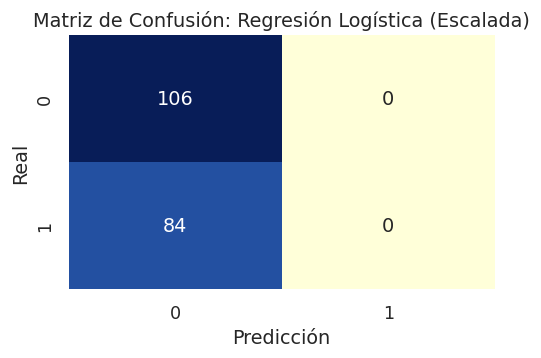


MODELO: K-Nearest Neighbors (Escalado)
Accuracy (ENTRENAMIENTO): 0.9333
Accuracy (PRUEBA):        0.9105
Diferencia (Train-Test):  0.0228

Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       106
           1       0.89      0.92      0.90        84

    accuracy                           0.91       190
   macro avg       0.91      0.91      0.91       190
weighted avg       0.91      0.91      0.91       190



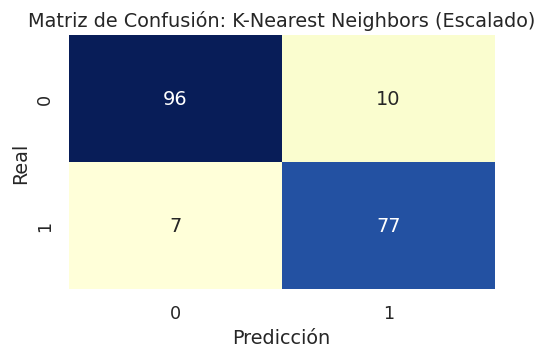


MODELO: Árbol de Decisión (Sin escalar)
Accuracy (ENTRENAMIENTO): 1.0000
Accuracy (PRUEBA):        0.8211
Diferencia (Train-Test):  0.1789

Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       106
           1       0.81      0.77      0.79        84

    accuracy                           0.82       190
   macro avg       0.82      0.82      0.82       190
weighted avg       0.82      0.82      0.82       190



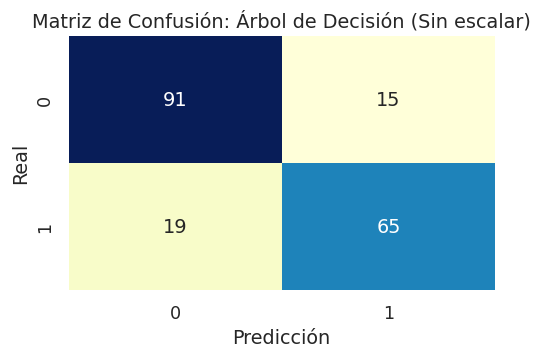

In [140]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Definición de modelos y pipelines
# El uso de Pipeline asegura que el StandardScaler solo haga 'fit' sobre el conjunto de entrenamiento,
# evitando que información del set de test se filtre durante el escalado (Data Leakage).

models = {
    "Regresión Logística (Escalada)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(random_state=SEED))
    ]),
    "K-Nearest Neighbors (Escalado)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())
    ]),
    "Árbol de Decisión (Sin escalar)": Pipeline([
        ("clf", DecisionTreeClassifier(random_state=SEED))
    ])
}

# Entrenamiento e iteración para evaluación
for name, model_pipeline in models.items():
    # Ajuste del pipeline completo
    model_pipeline.fit(X_train, y_train)

    # Predicciones para diagnóstico de Overfitting/Underfitting
    y_pred_train = model_pipeline.predict(X_train)
    y_pred_test = model_pipeline.predict(X_test)

    # Cálculo de métricas
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    # Reporte de resultados
    print(f"\n{'='*60}")
    print(f"MODELO: {name}")

    # Comentario vital: Comparar ambas métricas permite detectar si el modelo está memorizando (Overfitting)
    # o si es incapaz de aprender los patrones básicos (Underfitting).
    print(f"Accuracy (ENTRENAMIENTO): {acc_train:.4f}")
    print(f"Accuracy (PRUEBA):        {acc_test:.4f}")
    print(f"Diferencia (Train-Test):  {abs(acc_train - acc_test):.4f}")

    print("\nReporte de Clasificación (Conjunto de Prueba):")
    print(classification_report(y_test, y_pred_test))

    # Matriz de Confusión (Evaluada en Prueba)
    plt.figure(figsize=(5, 3))
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
    plt.title(f'Matriz de Confusión: {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

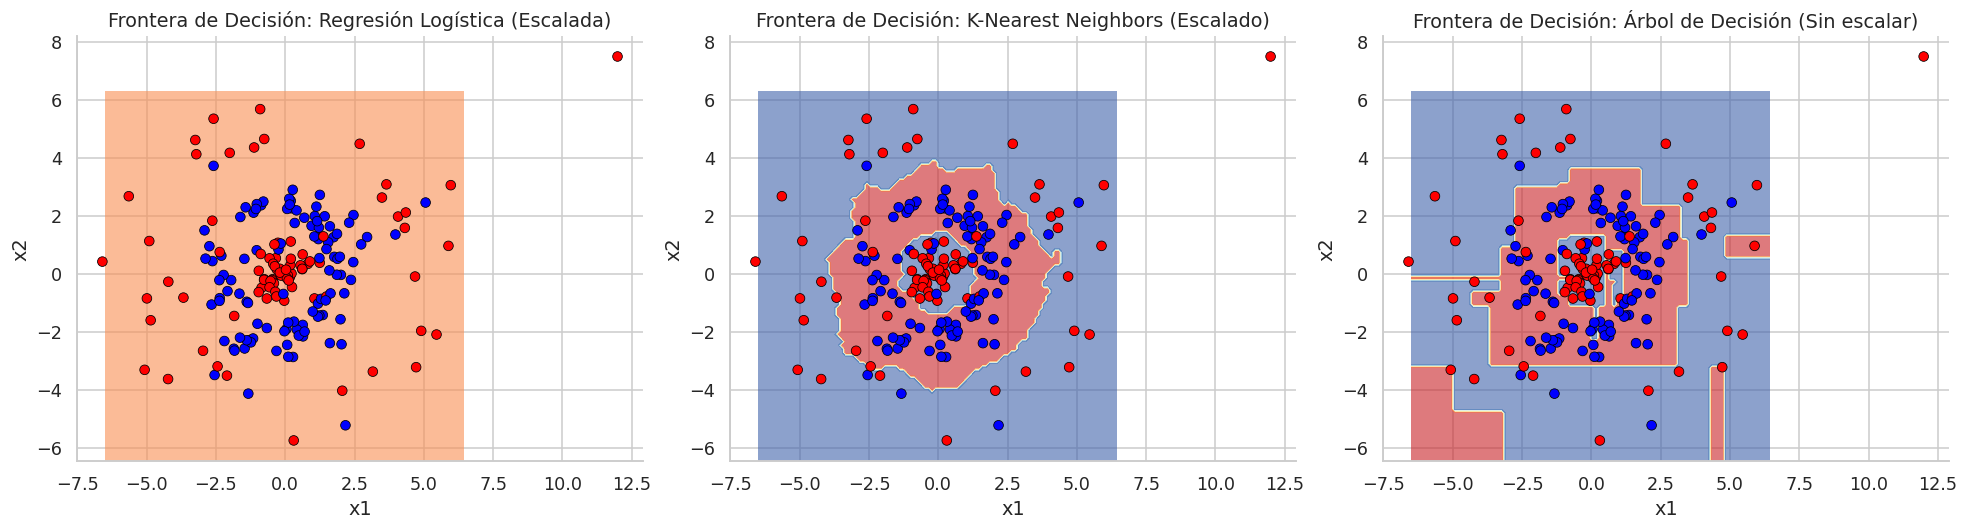

In [141]:
from sklearn.inspection import DecisionBoundaryDisplay

# Configuración de la figura con 3 subgráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Iteramos sobre los modelos ya entrenados en el diccionario 'models'
for ax, (name, pipeline) in zip(axes, models.items()):
    # 1. Graficamos las regiones de decisión
    # Nota: El pipeline ya incluye el escalado (StandardScaler) si fue necesario,
    # por lo que el DecisionBoundaryDisplay lo maneja automáticamente al predecir.
    DecisionBoundaryDisplay.from_estimator(
        pipeline,
        X_train,
        ax=ax,
        response_method="predict",
        cmap="RdYlBu",
        alpha=0.6
    )

    # 2. Superponemos los datos de prueba (X_test) con sus etiquetas reales
    sns.scatterplot(
        x=X_test[FEATURES[0]],
        y=X_test[FEATURES[1]],
        hue=y_test,
        palette={0: "blue", 1: "red"},
        edgecolor="black",
        s=40,
        ax=ax
    )

    # Comentario técnico:
    # - En el modelo Lineal se observará una división recta que ignora la estructura circular (Underfitting).
    # - En KNN y Árboles se verá cómo las regiones se adaptan a la geometría curva de los datos.
    ax.set_title(f"Frontera de Decisión: {name}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.get_legend().remove()

plt.tight_layout()
plt.show()

### Conclusiones del modelado y comparación de resultados

Tras el entrenamiento y la evaluación de los modelos, se desprenden conclusiones relevantes sobre el comportamiento de los algoritmos en función de la estructura de los datos.

#### 1. Regresión Logística (Línea de base)
Este modelo presentó el desempeño más bajo, con un *accuracy* aproximado del 56%. Se observó una incapacidad crítica para detectar la clase 1 (Recall 0%), lo cual se explica porque la Regresión Logística es un modelo lineal que intenta trazar un límite recto. Dado que los datos presentan una separación circular, una frontera lineal resulta insuficiente, lo que deriva en un problema de **underfitting** por la excesiva simplicidad del modelo frente a la complejidad del problema.

#### 2. Modelos No Lineales: Árboles y KNN
Al implementar modelos con capacidad de capturar patrones no lineales, se logró una mejora sustancial en los resultados:
*   **Árbol de Decisión:** Se obtuvo un 82% de accuracy. Esto se debe a que el algoritmo realiza particiones sucesivas sobre las variables `x1` e `x2`, logrando adaptar el espacio de decisión a la forma circular observada en el EDA.
*   **KNN (K-Nearest Neighbors):** Se consolidó como el mejor modelo con un **91% de accuracy**. Al basarse en la proximidad entre puntos (vecindarios), se logró capturar con precisión la frontera curva. Fue fundamental el uso de `StandardScaler` dentro del Pipeline, ya que esto garantizó que las distancias para `x1` e `x2` se midieran en la misma escala, evitando distorsiones en los resultados.

#### 3. Rigurosidad Metodológica y Fiabilidad (Sin Data Leakage)
Se destaca la utilización de **Pipelines de Scikit-Learn** en todo el flujo de trabajo. Esta implementación asegura que las métricas obtenidas sean robustas, ya que el escalado de los datos se realizó exclusivamente sobre el conjunto de entrenamiento y se aplicó luego al de test. De esta manera, se garantizó la ausencia de **Data Leakage** (fuga de información), permitiendo que el modelo mantenga su capacidad de generalización ante datos no vistos.

---
### Análisis de la Regresión Logística (Modelo Lineal)

**¿La regresión logística logra capturar la estructura de los datos?**  
No. La Regresión Logística falló totalmente al intentar entender la forma circular de los datos. Al ser un modelo lineal, lo único que puede hacer es trazar una línea recta para separar los grupos. Como en ese caso la clase 1 está rodeada por la clase 0, no hay forma de que una línea recta los separe bien.

**¿Qué resultado esperábamos antes de entrenarla y qué obtuvimos realmente?**
*   **Lo que se esperaba:** Por lo que se vió en la etapa de exploración (EDA), ya había una noción de que le iba a ir mal al modelo. Al ver esos círculos concéntricos, era casi seguro que un modelo lineal iba a quedar muy simple (**Underfitting**) y no iba a ofrecer un resultado desempeñador.
*   **Lo que pasó realmente:** Los números confirmaron esta sospecha. El accuracy fue de ~56%, que es el equivalente a querer "adivinar" el resultado. Lo más claro fue el **Recall de 0% para la clase 1**, lo que nos muestra que el modelo directamente no 'vio' el círculo central y predijo casi todo como clase 0.